In [1]:
# Install Anomalib (The library containing PatchCore)
!pip install -q anomalib[full]

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.0/780.0 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.8/241.8 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.9/827.9 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━

In [3]:
from google.colab import drive
import os

drive.mount('/content/drive')

LEATHER_DIR = '/content/drive/MyDrive/leather'

if os.path.exists(LEATHER_DIR):
    print(f"✅ Found dataset at: {LEATHER_DIR}")
    print("Contents:", os.listdir(LEATHER_DIR))
else:
    print(f"❌ Error: Could not find path: {LEATHER_DIR}")
    print("Please check your Google Drive structure and update 'LEATHER'.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Found dataset at: /content/drive/MyDrive/leather
Contents: ['readme.txt', 'license.txt', 'train', 'ground_truth', 'test']


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Import Anomalib components
from anomalib.data import MVTecAD
from anomalib.models import Patchcore
from anomalib.engine import Engine
from anomalib.deploy import ExportType

# CONFIGURATION
# PatchCore uses a "Memory Bank".
# coreset_sampling_ratio: How much of the data to keep (0.1 = 10%).
# Higher = Better accuracy but slower RAM usage.
model = Patchcore(
    backbone="resnet18",
    pre_trained=True,
    coreset_sampling_ratio=0.1,
)

# DATA LOADERS
# Anomalib handles the complex loading/transforming for us
datamodule = MVTecAD(
    root="/content/drive/MyDrive",
    category="leather",
    train_batch_size=32,
    eval_batch_size=32,
    num_workers=2
)

datamodule.setup() # Prepare data

# TRAINING (Building the Memory Bank)
engine = Engine(
    accelerator="auto", # Uses GPU if available
    devices=1
)

print("🧠 Training PatchCore (Building Memory Bank)...")
engine.fit(model=model, datamodule=datamodule)
print("✅ Training Complete.")

INFO:lightning_fabric.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:lightning_fabric.utilities.rank_zero:TPU available: False, using: 0 TPU cores


🧠 Training PatchCore (Building Memory Bank)...


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer
INFO: 
  | Name           | Type           | Params | Mode 
----------------------------------------------------------
0 | pre_processor  | PreProcessor   | 0      | train
1 | post_processor | PostProcessor  | 0      | train
2 | evaluator      | Evaluator      | 0      | train
3 | model          | PatchcoreModel | 2.8 M  | train
----------------------------------------------------------
2.8 M     Trainable params
0         Non-trainable params
2.8 M     Total params
11.131    Total estimated model params size (MB)
19        Modules in train mode
69        Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name           | Type           | Params | Mode 
------------

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]



Selecting Coreset Indices.:   0%|          | 0/25088 [00:00<?, ?it/s]

Selecting Coreset Indices.:   0%|          | 1/25088 [00:00<52:19,  7.99it/s]

Selecting Coreset Indices.:   0%|          | 13/25088 [00:00<06:18, 66.30it/s]

Selecting Coreset Indices.:   0%|          | 34/25088 [00:00<03:16, 127.30it/s]

Selecting Coreset Indices.:   0%|          | 56/25088 [00:00<02:35, 161.12it/s]

Selecting Coreset Indices.:   0%|          | 80/25088 [00:00<02:13, 187.02it/s]

Selecting Coreset Indices.:   0%|          | 104/25088 [00:00<02:02, 203.88it/s]

Selecting Coreset Indices.:   1%|          | 129/25088 [00:00<01:55, 215.98it/s]

Selecting Coreset Indices.:   1%|          | 153/25088 [00:00<01:51, 223.09it/s]

Selecting Coreset Indices.:   1%|          | 178/25088 [00:00<01:49, 228.52it/s]

Selecting Coreset Indices.:   1%|          | 202/25088 [00:01<01:47, 230.73it/s]

Selecting Coreset Indices.:   1%|          | 226/25088 [00:01<01:46, 233.46it/s]

Selecting Coreset Indices.:   1%|

✅ Training Complete.


In [17]:
# RUN PREDICTIONS
print("🔍 Running Validation on Test Set...")
test_results = engine.test(model=model, datamodule=datamodule)

INFO:lightning_fabric.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


🔍 Running Validation on Test Set...


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │    0.9959238767623901     │
│       image_F1Score       │    0.9834254384040833     │
│        pixel_AUROC        │    0.9892233610153198     │
│       pixel_F1Score       │    0.37276896834373474    │
└───────────────────────────┴───────────────────────────┘

✅ Visualization Function Fixed.
Showing Example 1 (Check for defects):


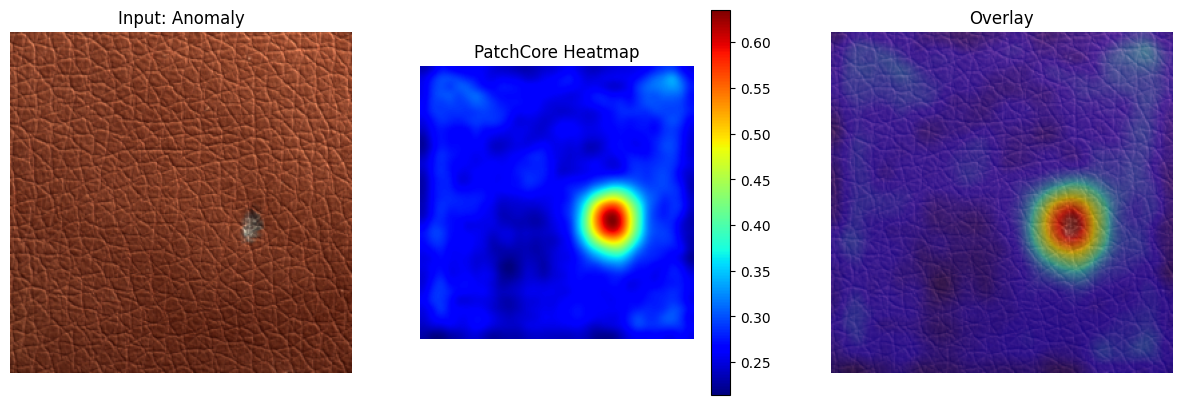

Showing Example 2:


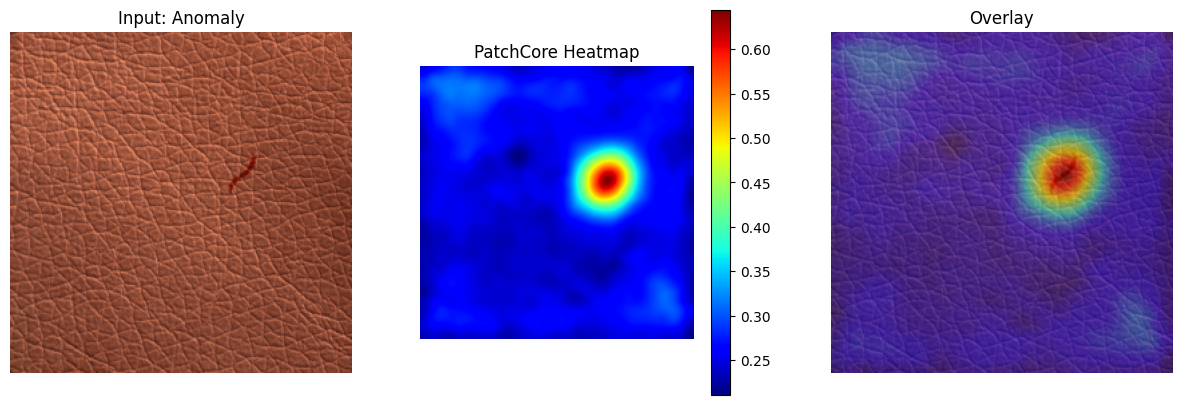

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# VISUALIZATION FUNCTION

from anomalib.utils.visualization import ImageVisualizer
from PIL import Image

def visualize_inference(index=0):
    # Get the test dataset
    test_loader = datamodule.test_dataloader()

    # Grab a batch
    batch = next(iter(test_loader))

    # Run Inference
    model.eval()

    # Move inputs to device (using dot notation for modern Anomalib)
    input_imgs = batch.image.to(model.device)

    # Forward pass
    with torch.no_grad():
        predictions = model(input_imgs)



    image = batch.image[index].cpu().numpy().transpose(1, 2, 0)

    # Access the anomaly map from the prediction object
    if isinstance(predictions, torch.Tensor):
        # If model returns just a tensor, it is the anomaly map
        anomaly_map = predictions[index].cpu().numpy()
    elif hasattr(predictions, 'anomaly_map'):
        # If it returns an InferenceBatch object
        anomaly_map = predictions.anomaly_map[index].cpu().numpy()
    else:
        # Fallback for dictionary output
        anomaly_map = predictions['anomaly_map'][index].cpu().numpy()

    # Squeeze to remove the channel dim: (1, 256, 256) -> (256, 256)
    anomaly_map = anomaly_map.squeeze()

    gt_label_int = batch.gt_label[index].item()
    gt_label = "Anomaly" if gt_label_int == 1 else "Normal"

    # Normalize Image for display
    image = (image - image.min()) / (image.max() - image.min())

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original Image
    axes[0].imshow(image)
    axes[0].set_title(f"Input: {gt_label}")
    axes[0].axis('off')

    # Anomaly Heatmap
    im = axes[1].imshow(anomaly_map, cmap='jet')
    axes[1].set_title("PatchCore Heatmap")
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1])

    # Overlay
    axes[2].imshow(image)
    axes[2].imshow(anomaly_map, cmap='jet', alpha=0.5) # Overlay
    axes[2].set_title("Overlay")
    axes[2].axis('off')

    plt.show()

print("✅ Visualization Function Fixed.")

# Show a few examples
print("Showing Example 1 (Check for defects):")
visualize_inference(index=0)
print("Showing Example 2:")
visualize_inference(index=1)

INFO:lightning_fabric.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


gathering predictions...


Predicting: |          | 0/? [00:00<?, ?it/s]

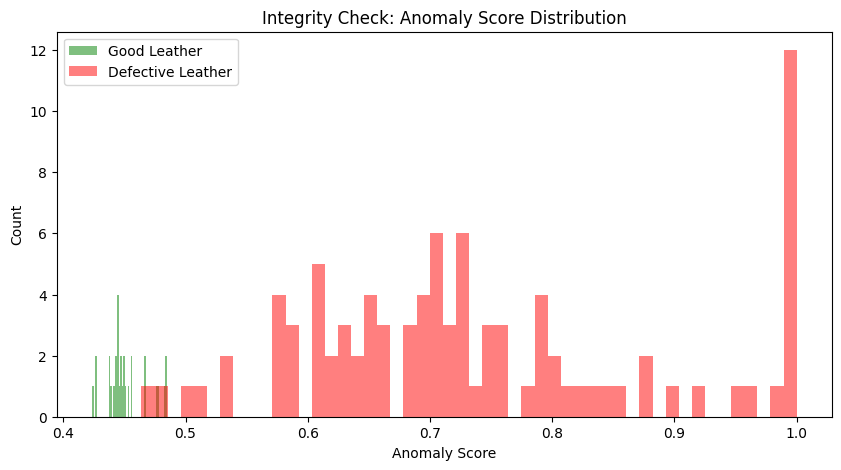

If the Green and Red distributions are separated, your model is solid!


In [22]:
import matplotlib.pyplot as plt

def plot_evaluation_graphs(engine, datamodule):
    print("gathering predictions...")
    test_results = engine.predict(model=model, datamodule=datamodule)

    # Extract scores and labels
    pred_scores = []
    ground_truth = []

    for batch in test_results:
        if hasattr(batch, 'pred_score'):
            pred_scores.extend(batch.pred_score.cpu().numpy())
        if hasattr(batch, 'gt_label'):
            ground_truth.extend(batch.gt_label.cpu().numpy())

    # Plot Histogram
    plt.figure(figsize=(10, 5))
    plt.hist([s for s, l in zip(pred_scores, ground_truth) if l == 0],
             bins=50, alpha=0.5, color='green', label='Good Leather')
    plt.hist([s for s, l in zip(pred_scores, ground_truth) if l == 1],
             bins=50, alpha=0.5, color='red', label='Defective Leather')
    plt.title("Integrity Check: Anomaly Score Distribution")
    plt.xlabel("Anomaly Score")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

    print("If the Green and Red distributions are separated, your model is solid!")


plot_evaluation_graphs(engine, datamodule)